This is associated with video 3/10 from Andrej Karpathy Neural Networks: Zero to Hero.  

In [20]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt 
%matplotlib inline

In [21]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [22]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [111]:
# build the data set
block_size = 3 # context length: how many characters do we take to predict the next one?

X, Y = [], []
for w in words:
    context = [0] * block_size # 
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context) # The list X gets a new list inside of length block_size
        Y.append(ix) # the list Y gets the integer for the character added to it
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [32]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [153]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?

    X, Y = [], []
    for w in words:
        context = [0] * block_size # 
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context) # The list X gets a new list inside of length block_size
            Y.append(ix) # the list Y gets the integer for the character added to it
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
C = torch.randn(27,2) # each of the 27 characters has 2 embeddings
C

tensor([[ 1.3885, -1.2207],
        [ 1.3617, -1.1267],
        [ 0.9886, -0.1084],
        [-0.9409,  1.2307],
        [ 0.3893,  0.2074],
        [-0.0246, -0.1669],
        [-1.4586, -0.9200],
        [ 1.5383, -0.9572],
        [ 1.2943,  0.0112],
        [ 1.2483,  1.7508],
        [-2.2098, -0.0508],
        [-0.1201,  0.4106],
        [ 0.3242,  1.5304],
        [-0.6895,  1.5974],
        [ 0.2531, -0.6013],
        [-0.9675,  0.6407],
        [-0.6994,  0.6673],
        [ 0.4575, -0.0529],
        [ 0.8071, -1.0857],
        [ 0.6305,  1.9308],
        [ 1.4776,  0.5110],
        [ 0.5502, -1.8416],
        [ 0.6690, -0.1710],
        [ 1.0233,  1.0060],
        [-1.4652, -0.6937],
        [ 1.2664, -0.6040],
        [-1.0517,  0.7447]])

In [50]:
# C is a lookup table is 27 rows, one per character, and 2 columns. The 2 valuies in each row are just random numbers for now.
# C having 2 columns is arbitrary
# The embedding just converts every row of X into a 2 column embedding vector.

emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [51]:
W1 = torch.randn((6, 100)) # 6 is 3x2, so the 3 block_length times the two embedding vector length. 100 is an arbitrary number of neurons.
b1 = torch.randn(100)

In [69]:
# We need to multiply embeddings (32, 3, 2) by the weights (6, 100), so we need to convert the embeddings to a (32 x 6) matrix first
# We want 
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # This code doesn't generalize to block size
# torch.cat(torch.unbind(emb, 1), 1).shape # does the same thing
# emb.view(32,6) == torch.cat(torch.unbind(emb, 1), 1) # does the same thing

h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # hidden layer of 100 activations for every one of our 32 examples


In [70]:
W2 = torch.randn((100, 27)) # 6 is 3x2, so the 3 block_length times the two embedding vector length. 100 is an arbitrary number of neurons.
b2 = torch.randn(27)

In [71]:
logits = h @ W2 + b2

In [72]:
logits.shape

torch.Size([32, 27])

In [73]:
counts = logits.exp()

In [74]:
prob = counts / counts.sum(1, keepdims = True)

In [84]:
prob.shape

torch.Size([32, 27])

In [ ]:
# Prob is 32x27, so 32 next characters, and 27 possible characters in the vocab. So for each position in our input 32, 
# prob gives the probability that each of those next characters is any from the vocab

# So prob[2,:] gives the probability, given 'em', of the next chararacter. So it gives a 27 length vector of probabilities, one for each letter

# So prob[torch.arange(32), Y] gives a 32 length vector, one for each input (input = 3 base unit chunk)
# So the first element of this is the model's probability that the next letter, given '...', is 'e'
# So the second element of this is the model's probability that the next letter, given '..e', is 'm'
# So this vector is the probability that the model predicted the correct next letter, given the input of the 3 letters.

prob[torch.arange(32), Y]


tensor([7.7831e-06, 3.0112e-13, 7.6578e-07, 2.9417e-01, 3.0610e-13, 3.0277e-11,
        3.6628e-08, 3.1916e-11, 1.2621e-08, 1.2557e-08, 1.2613e-08, 9.4466e-07,
        9.0809e-09, 1.7417e-02, 5.2077e-05, 8.6109e-07, 1.2694e-04, 1.5301e-15,
        9.8222e-01, 6.2531e-08, 1.5726e-10, 9.6692e-11, 3.8246e-13, 9.8799e-01,
        7.4634e-12, 1.8693e-09, 1.5600e-09, 3.3585e-09, 1.8907e-13, 6.8062e-09,
        2.6283e-07, 2.5327e-05])

In [97]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.4481)

In [98]:
# ------------- cleaned up a bit ---------------

In [154]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [209]:
g = torch.Generator().manual_seed(214783647)
C = torch.randn((27,10), generator = g)
W1 = torch.randn((30, 200), generator = g)
b1 = torch.randn(200, generator = g)
W2 = torch.randn((200,27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]



In [210]:
sum(p.nelement() for p in parameters)

11897

In [211]:
for p in parameters:
    p.requires_grad = True

In [212]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [213]:
lri = []
lossi = []
stepi = []

In [214]:
for i in range(200000):

    # mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims= True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix]) # calcualtes same loss as the commented lines above
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item())


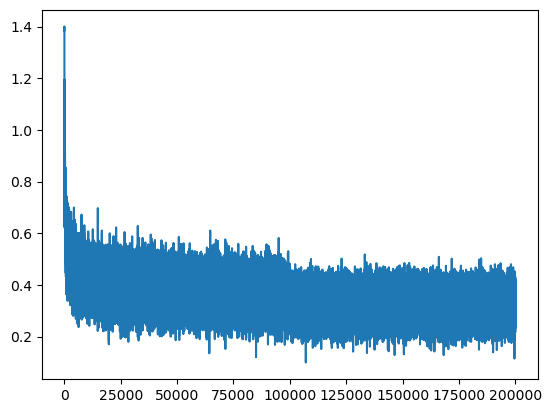

In [215]:
plt.plot(stepi, lossi)

In [216]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) # calcualtes same loss as the commented lines above
loss

tensor(2.1726, grad_fn=<NllLossBackward0>)

In [217]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) # calcualtes same loss as the commented lines above
loss

tensor(2.1266, grad_fn=<NllLossBackward0>)

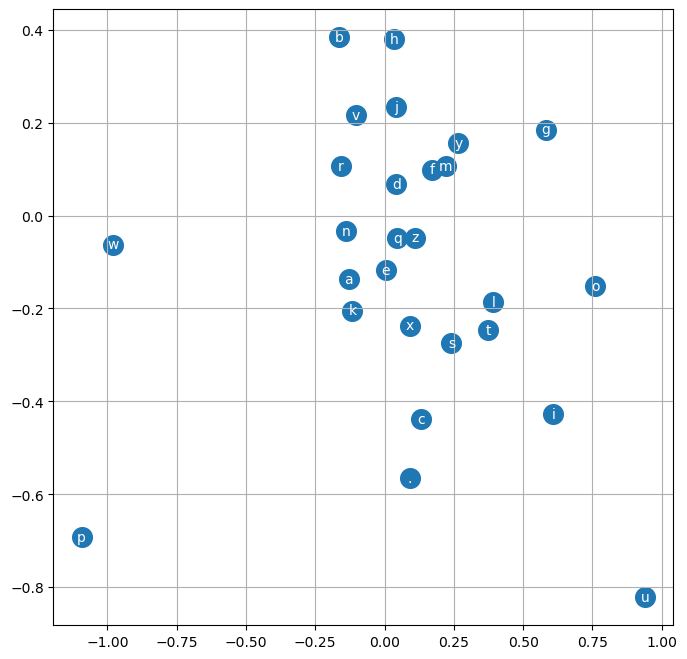

In [208]:
# Visualize embeddings
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data, C[:,1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha = 'center', va = 'center', color = 'white')
plt.grid('minor')

# X and Y are columns of C
# What do the numbers mean?
# some clustering among vowels and consonants
# q looks like an outlier, same with '.' 

# The constraint to perforrmance might be that there's only a 2 dimensional embedding, maybe we can increase that.


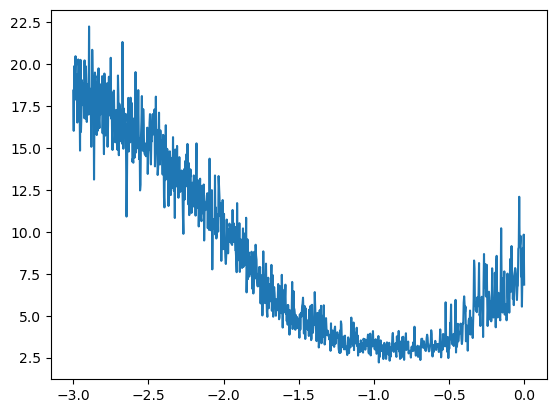

In [ ]:
plt.plot(lri, lossi)
# best exponent is ~ 1.0
# 10^-1 = 0.1


In [218]:
# sample from the model
g = torch.Generator().manual_seed(214783647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

ryel.
emoklyn.
yanj.
elii.
lesayon.
zen.
maxabeam.
limwy.
evechtirore.
den.
kel.
hazaelysen.
araiah.
evmarl.
darsam.
odi.
cramora.
loyani.
eighlilly.
nyvion.
